**0. Import requireed modules**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
import torch
from transformers import BitsAndBytesConfig
import torch
from transformers import AutoTokenizer, AutoModel
from pathlib import Path

**1. Provide the path of java files and load their source code into a list**

In [ ]:
from pathlib import Path


SOURCE_CODE_DIR = Path("/content/drive/MyDrive/mapreduce")

OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
files_list = []
# .rglob() searches the root folder and all sub-folders automatically
for file_path in SOURCE_CODE_DIR.rglob('*.java'):
    if file_path.is_file():
        with open(file_path, 'r', encoding='utf-8') as f:
            files_list.append(f.read())

In [ ]:
print(f"Checking for .java files in: {SOURCE_CODE_DIR}")
java_files_found = list(SOURCE_CODE_DIR.rglob('*.java'))
if java_files_found:
    print(f"Found {len(java_files_found)} .java files. Listing first 5 (if any):\n{java_files_found[:5]}")
else:
    print("No .java files found in the specified directory or its subdirectories.")
    print("Please ensure the path is correct and contains Java source code.")

Checking for .java files in: /content/drive/MyDrive/mapreduce
Found 332 .java files. Listing first 5 (if any):
[PosixPath('/content/drive/MyDrive/mapreduce/MapContext.java'), PosixPath('/content/drive/MyDrive/mapreduce/JobSubmissionFiles.java'), PosixPath('/content/drive/MyDrive/mapreduce/ClusterMetrics.java'), PosixPath('/content/drive/MyDrive/mapreduce/InputFormat.java'), PosixPath('/content/drive/MyDrive/mapreduce/Mapper.java')]


**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [ ]:
from google.colab import userdata  # <--- Add this import line

try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

**3. Hardware optimization (Quantization)**

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # What is loaded in 4 bit? why?
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

**4. Generate embeddings**

In [ ]:
embedding_model_name = "ibm-granite/granite-embedding-english-r2"

In [ ]:
!pip install -U transformers tokenizers huggingface_hub accelerate

  Using cached tokenizers-0.23.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.8 kB)


In [ ]:
embedding_model_name = "ibm-granite/granite-embedding-english-r2"

tokenizer = AutoTokenizer.from_pretrained(embedding_model_name, token=hf_token, trust_remote_code=True)
model = AutoModel.from_pretrained(embedding_model_name, token=hf_token, trust_remote_code=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Loaded {embedding_model_name} onto {device}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

Loaded ibm-granite/granite-embedding-english-r2 onto cuda


5.Construct the semantic similarity matrix

In [ ]:
def embed_source_code(code_list, batch_size=8):
    all_embeddings = []
    for i in range(0, len(code_list), batch_size):
        batch_code = code_list[i:i + batch_size]
        # Tokenize the input code list
        encoded_input = tokenizer(batch_code, padding=True, truncation=True, max_length=512, return_tensors='pt').to(device)

        # Generate embeddings
        with torch.no_grad():
            model_output = model(**encoded_input)
            # The last hidden state contains the embeddings
            # Apply mean pooling to get a fixed-size vector for each code snippet
            embeddings = model_output.last_hidden_state.mean(dim=1)
        # Convert to float32 before moving to CPU and then to numpy
        all_embeddings.append(embeddings.float().cpu().numpy())

    return np.vstack(all_embeddings)

In [ ]:
embeddings = embed_source_code(files_list)
semantic_matrix = cosine_similarity(embeddings)

## **6. Construct the structural similarity matrix**

In [ ]:
import numpy as np

def read_rsf_dependencies(rsf_file_path):
    dependencies = []
    try:
        with open(rsf_file_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 3:
                    dep_type, source, target = parts
                    dependencies.append((dep_type, source, target))
    except FileNotFoundError:
        print(f"Error: RSF file not found at {rsf_file_path}")
    return dependencies

def build_structural_matrix(java_file_paths, dependencies):
    num_files = len(java_file_paths)
    matrix = np.zeros((num_files, num_files))

    # Create robust mappings from simple class names and file names to their indices
    file_map = {}
    for i, path_obj in enumerate(java_file_paths):
        file_map[path_obj.name] = i  # e.g., 'MapContext.java' -> 0
        file_map[path_obj.stem] = i  # e.g., 'MapContext' -> 0 (for direct class name matches)

    # Initialize adjacency lists for directed graph
    # For each file (by index), store a set of indices of files it depends on (outgoing)
    outgoing_dependencies = {i: set() for i in range(num_files)}
    # For each file (by index), store a set of indices of files that depend on it (incoming)
    incoming_dependencies = {i: set() for i in range(num_files)}

    for dep_type, source_rsf, target_rsf in dependencies:
        # Extract simple class names from RSF entries
        # Assuming RSF entries are fully qualified class names like 'org.apache.hadoop.mapreduce.Cluster'
        simple_source_name = source_rsf.split('.')[-1]
        simple_target_name = target_rsf.split('.')[-1]

        source_idx = file_map.get(simple_source_name + ".java") or file_map.get(simple_source_name)
        target_idx = file_map.get(simple_target_name + ".java") or file_map.get(simple_target_name)

        if source_idx is not None and target_idx is not None:
            if source_idx != target_idx:  # A file doesn't depend on itself in structural graphs
                outgoing_dependencies[source_idx].add(target_idx)
                incoming_dependencies[target_idx].add(source_idx)

    for i in range(num_files):
        for j in range(num_files):
            if i == j:
                matrix[i, j] = 1.0
            else:
                score = 0

                # 1. Direct dependency (i depends on j OR j depends on i)
                if j in outgoing_dependencies[i] or i in outgoing_dependencies[j]:
                    score += 1

                # 2. Shared outgoing dependencies (i and j both depend on some k)
                shared_out = len(outgoing_dependencies[i].intersection(outgoing_dependencies[j]))
                score += shared_out

                # 3. Shared incoming dependencies (some k depends on both i and j)
                shared_in = len(incoming_dependencies[i].intersection(incoming_dependencies[j]))
                score += shared_in

                matrix[i, j] = score

    return matrix

# Placeholder for the RSF file path
RSF_FILE_PATH = Path("/content/mapreduce_filtered.rsf")

# Get the list of java file paths from SOURCE_CODE_DIR
java_file_paths = list(SOURCE_CODE_DIR.rglob('*.java'))

# Read dependencies from the (yet to be provided) RSF file
raw_dependencies = read_rsf_dependencies(RSF_FILE_PATH)

# Build the structural matrix
struct_matrix_raw = build_structural_matrix(java_file_paths, raw_dependencies)

print("Structural matrix (raw) created. Please ensure RSF_FILE_PATH and read_rsf_dependencies are correctly implemented.")
print(f"Shape of struct_matrix_raw: {struct_matrix_raw.shape}")

Structural matrix (raw) created. Please ensure RSF_FILE_PATH and read_rsf_dependencies are correctly implemented.
Shape of struct_matrix_raw: (332, 332)


**7. Normalize the structural matrix**

In [ ]:
max_overlap = struct_matrix_raw.max()
struct_matrix = struct_matrix_raw / max_overlap if max_overlap > 0 else struct_matrix_raw
np.fill_diagonal(struct_matrix, 1.0)

**8. Combine the two matrices into one similarity matrix then apply complement.**

In [ ]:

ALPHA = 0.5  # Set ALPHA to a numerical value
combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Invert similarity to get distance
distance_matrix = 1.0 - combined_similarity
np.fill_diagonal(distance_matrix, 0)

In [ ]:
print(distance_matrix)

[[0.         0.61046559 0.6237956  ... 0.59504855 0.58146024 0.61223626]
 [0.61046559 0.         0.59008324 ... 0.61322558 0.59326559 0.56449172]
 [0.6237956  0.59008324 0.         ... 0.61646917 0.59250665 0.58947068]
 ...
 [0.59504855 0.61322558 0.61646917 ... 0.         0.59653437 0.61964917]
 [0.58146024 0.59326559 0.59250665 ... 0.59653437 0.         0.52397865]
 [0.61223626 0.56449172 0.58947068 ... 0.61964917 0.52397865 0.        ]]


In [ ]:
print(f"The distance matrix has {distance_matrix.shape[0]} rows and {distance_matrix.shape[1]} columns.")

The distance matrix has 332 rows and 332 columns.


**9. Apply clustering**

In [ ]:
TARGET_NUM_CLUSTERS = 10  # Set TARGET_NUM_CLUSTERS to a numerical value
clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric='precomputed', linkage='complete') # what is 'precomputed' & 'linkage'?
clusters = clusterer.fit_predict(distance_matrix)

**10. Visulizations**

/tmp/ipykernel_6808/4237917168.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(distance_matrix, 'complete')


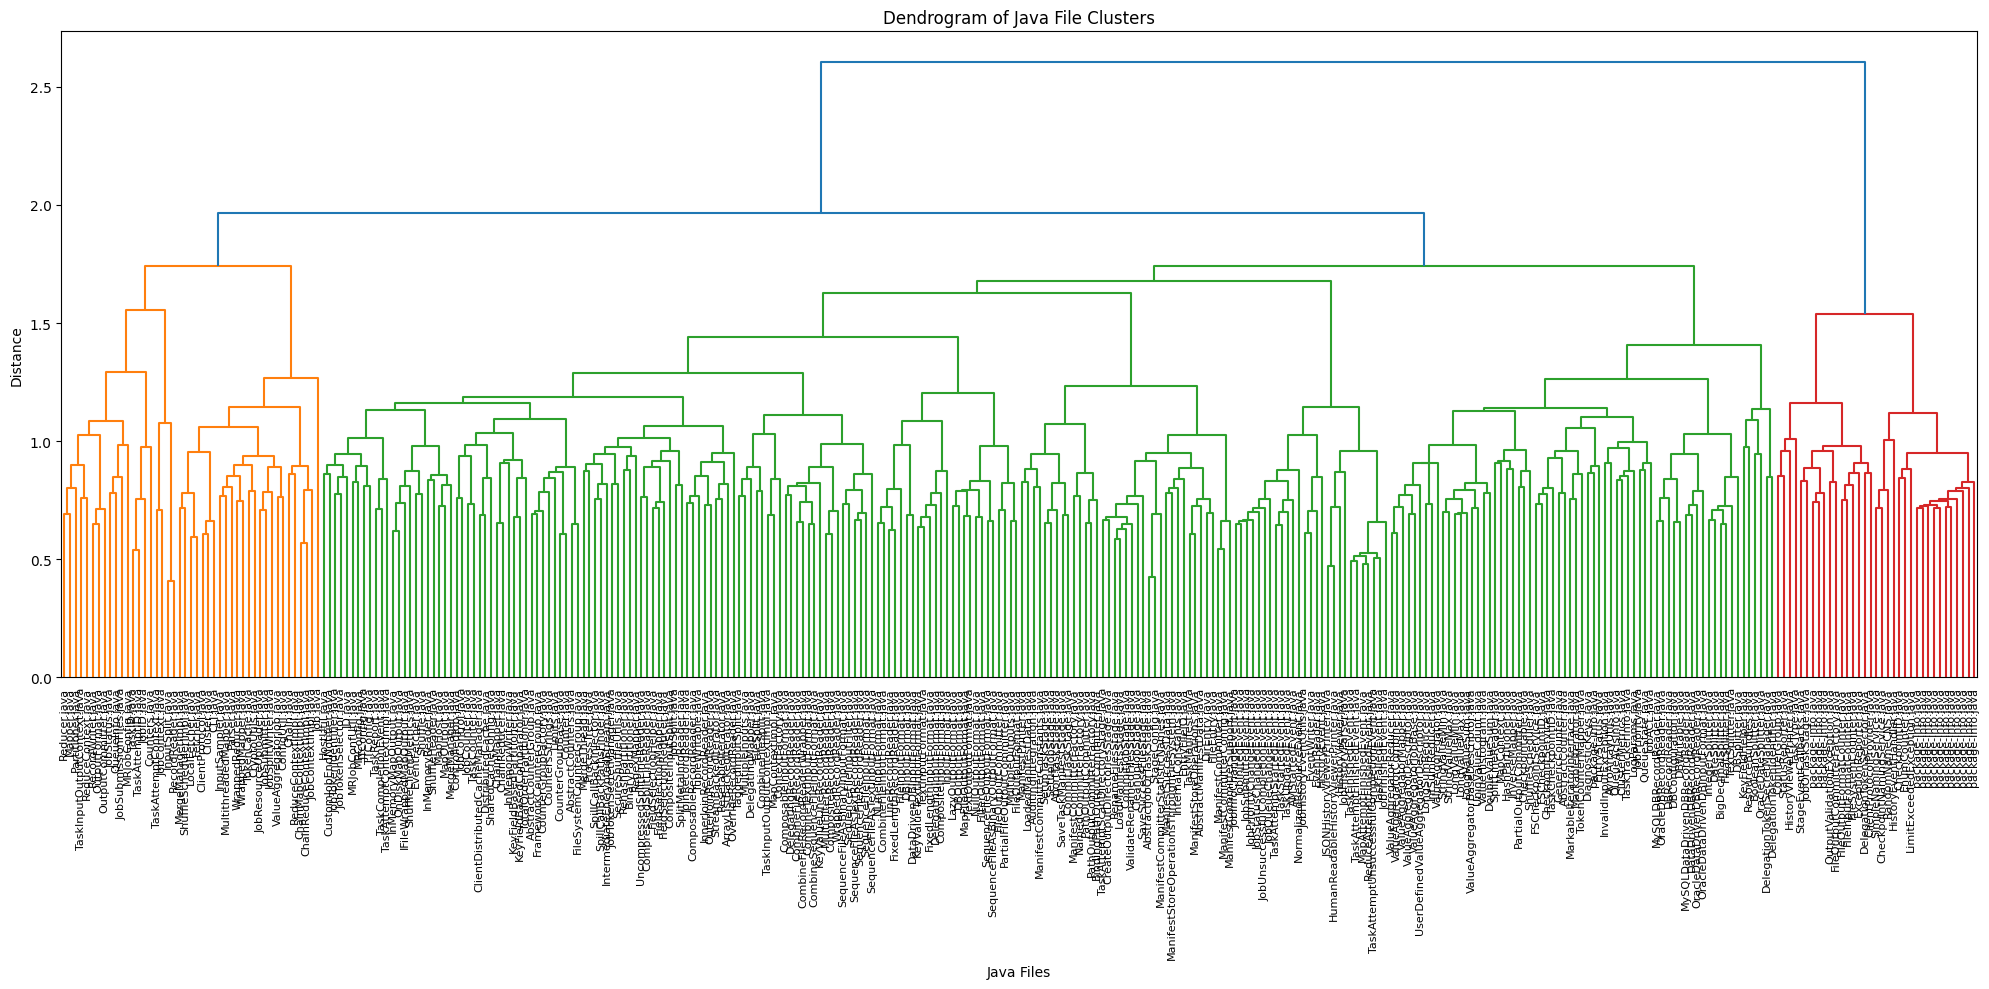

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering on the distance matrix
# 'complete' linkage is used to match the AgglomerativeClustering parameter
linked = linkage(distance_matrix, 'complete')

plt.figure(figsize=(20, 10))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=8,
    labels=[Path(f).name for f in java_file_paths] # Use file names as labels
)
plt.title('Dendrogram of Java File Clusters')
plt.xlabel('Java Files')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:
rsf_data_lines = []

for cluster_id, file_path_obj in zip(clusters, java_file_paths):
    file_name = file_path_obj.name
    rsf_entry = f"contain cluster_{cluster_id} {file_name}"
    rsf_data_lines.append(rsf_entry)

print(f"Generated {len(rsf_data_lines)} RSF data lines. First 5 lines:\n{rsf_data_lines[:5]}")

output_rsf_path = OUTPUT_DIR / "week3_arc_clusters.rsf"

with open(output_rsf_path, 'w') as f:
    for line in rsf_data_lines:
        f.write(line + '\n')

print(f"Successfully wrote {len(rsf_data_lines)} RSF entries to {output_rsf_path}")

Generated 332 RSF data lines. First 5 lines:
['contain cluster_2 MapContext.java', 'contain cluster_4 JobSubmissionFiles.java', 'contain cluster_2 ClusterMetrics.java', 'contain cluster_2 InputFormat.java', 'contain cluster_2 Mapper.java']
Successfully wrote 332 RSF entries to /content/output/week3_arc_clusters.rsf


Generating the improved 2D Architecture Map...


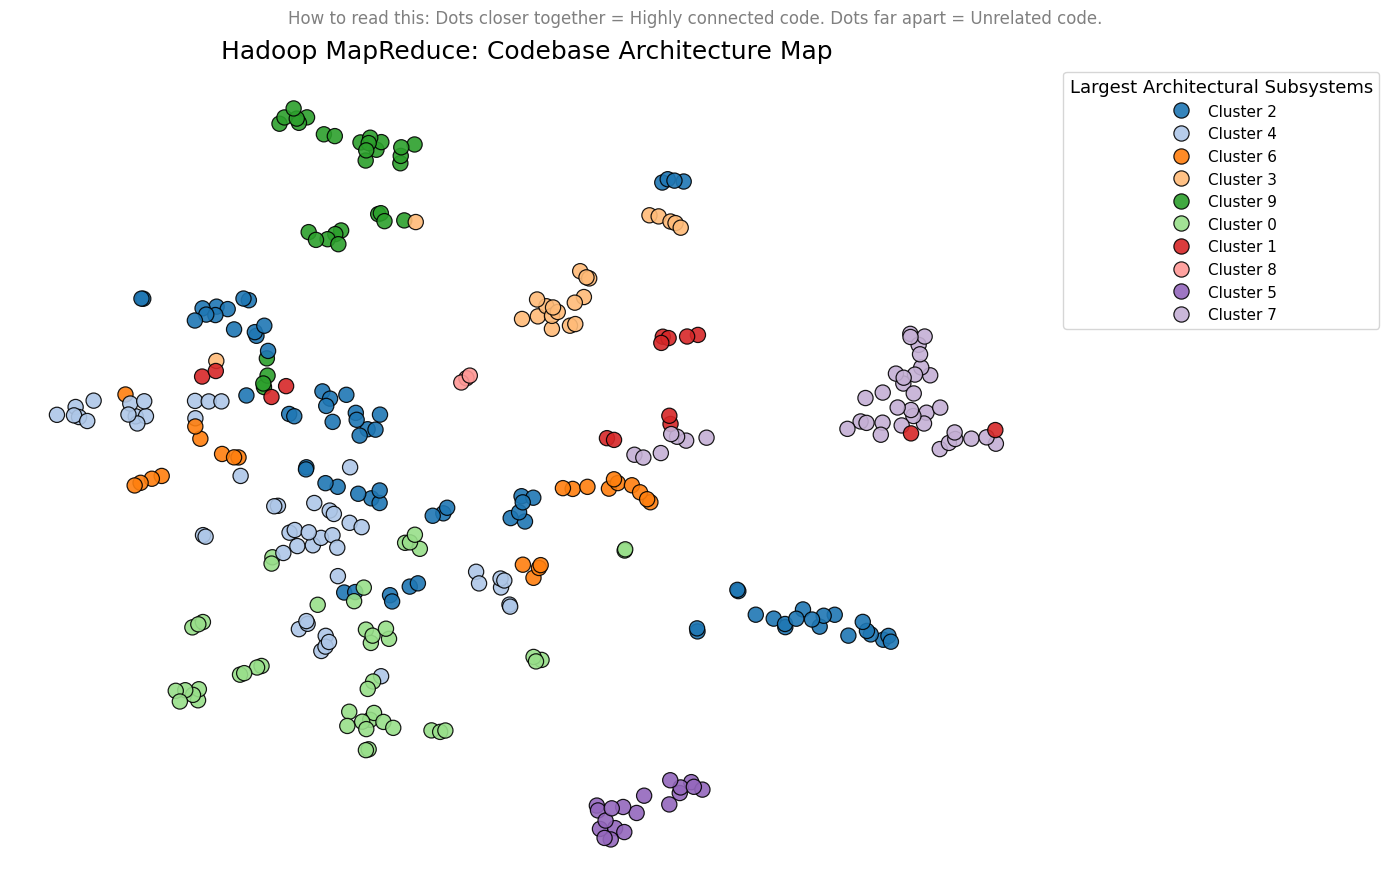

Visualization Complete!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE

print("Generating the improved 2D Architecture Map...")

# 1. Squash the complex math into a flat 2D layout
tsne = TSNE(n_components=2, metric='precomputed', random_state=42, init='random', perplexity=5)
coords_2d = tsne.fit_transform(distance_matrix)

# 2. Package the data cleanly
df = pd.DataFrame({
    'Distance X': coords_2d[:, 0],
    'Distance Y': coords_2d[:, 1],
    'Cluster': clusters,
    'File': files_list
})

# 3. Create a clean legend label.
# We only show the top 15 biggest clusters in the legend, otherwise it ruins the image!
top_clusters = df['Cluster'].value_counts().nlargest(15).index
df['Legend_Label'] = df['Cluster'].apply(lambda c: f"Cluster {c}" if c in top_clusters else "Other Small Clusters")

# 4. Create the final, clean plot
plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=df,
    x='Distance X',
    y='Distance Y',
    hue='Legend_Label',
    palette='tab20',
    s=120,           # Slightly larger dots
    alpha=0.9,
    edgecolor='black'
)

# 5. Move the legend OUTSIDE the graph box
plt.legend(title="Largest Architectural Subsystems", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=11, title_fontsize=13)

# 6. Proper, understandable titles
plt.title("Hadoop MapReduce: Codebase Architecture Map", fontsize=18, pad=10)
plt.suptitle("How to read this: Dots closer together = Highly connected code. Dots far apart = Unrelated code.", fontsize=12, color='gray')

# 7. Remove the actual axis numbers and lines because the literal X/Y coordinates don't mean anything
plt.xticks([])
plt.yticks([])
sns.despine(left=True, bottom=True)
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()
print("Visualization Complete!")

/tmp/ipykernel_6808/3424371327.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


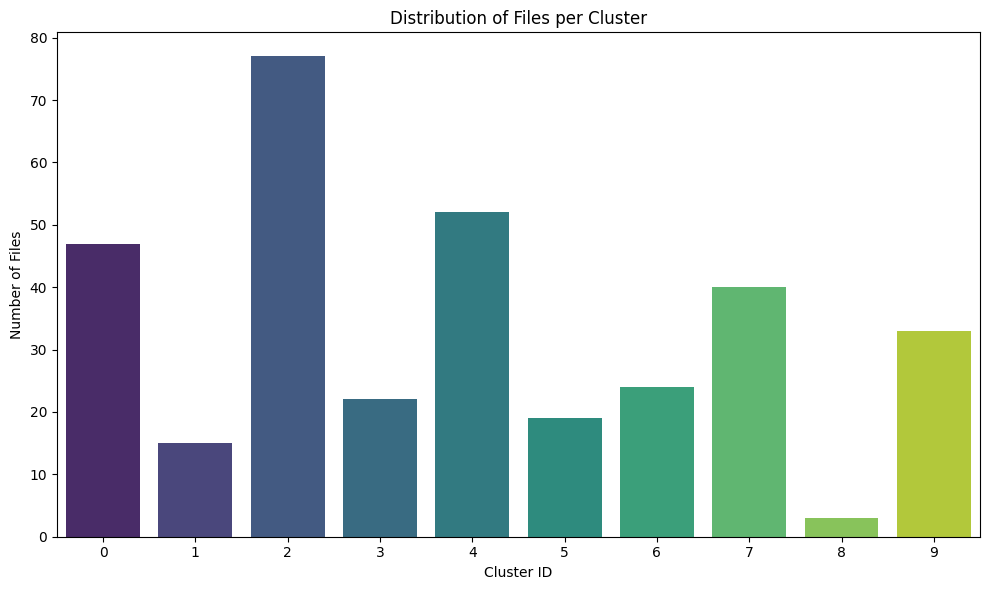

Cluster distribution visualization complete.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for easier plotting
cluster_counts = pd.Series(clusters).value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.title('Distribution of Files per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Files')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Cluster distribution visualization complete.")